# Statistical Validation - Sitting - M1 vs M2

## Section 0 - Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy.stats import shapiro
import warnings
import logging
from pathlib import Path

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

DATA_PATH  = Path(
    r'C:\Projects\Scripts_results_analysis_plots\Intermodel comparison'
    r'\grab7\Sitting\Mean_SD_comparison\Comparacion_Modelos_Sentado.xlsx'
)
OUTPUT_DIR = Path(
    r'C:\Projects\Scripts_results_analysis_plots\Intermodel comparison'
    r'\grab7\Sitting\Mean_SD_comparison\results'
)
OUTPUT_DIR.mkdir(exist_ok=True)

# TFG display-name mapping: CSV value -> display name
MODEL_DISPLAY = {'C7': 'M1', 'NOT_C7': 'M2'}
# Reverse: display name -> CSV value
MODEL_CSV     = {'M1': 'C7', 'M2': 'NOT_C7'}
MODEL_ORDER   = ['M1', 'M2']

MOVEMENTS_UNILATERAL = [
    'Shoulder Flex/Ext',
    'Shoulder Abd/Add',
    'Shoulder Int/Ext Rot',
    'Elbow Flex/Ext',
]
MOVEMENTS_BILATERAL = [
    'Trunk Extended Lateral Inclination',
    'Thorax Lateral Inclination',
]
MOVEMENT_LIST = MOVEMENTS_UNILATERAL + MOVEMENTS_BILATERAL

ANGLE_VARS = ['Peak_deg', 'Valley_deg', 'ROM_deg']
VAR_LABELS = {
    'Peak_deg':   'Peak (deg)',
    'Valley_deg': 'Valley (deg)',
    'ROM_deg':    'ROM (deg)',
}


def get_sides(movement):
    return ['Left'] if movement in MOVEMENTS_BILATERAL else ['Left', 'Right']


def get_array(dataframe, movement, model, side, var):
    # model: display name (M1/M2); mapped to CSV value internally.
    csv_model = MODEL_CSV.get(model, model)
    col  = f'{side}_{var}'
    mask = (
        (dataframe['Movement'] == movement) &
        (dataframe['Model']    == csv_model)
    )
    return dataframe[mask].sort_values('Rep')[col].to_numpy(dtype=float)


print('Configuration loaded.')


Configuration loaded.


## Section 1 - Data Loading and Validation

In [2]:
def _build_flat_df(xlsx_path):
    # Parse multi-section Sentado Excel to a flat tidy DataFrame.
    # Column index mapping (from the Excel header row after each movement block):
    #  4=Left Peak, 7=Left Valley, 8=Left ROM
    # 11=Right Peak, 14=Right Valley, 15=Right ROM (unilateral only)
    raw = pd.read_excel(xlsx_path, header=None, dtype=str)
    raw = raw.fillna('').values.tolist()
    records  = []
    movement = None
    bilateral = False

    for row in raw:
        cols = [str(c).strip() for c in row]
        while cols and cols[-1] == '':
            cols.pop()
        if not cols:
            continue

        is_data_val = cols[0] in ('Model', 'C7', 'NOT_C7')
        is_section  = (not is_data_val) and (
            len(cols) == 1 or all(c == '' for c in cols[1:])
        )

        if is_section:
            name      = cols[0]
            bilateral = 'Bilateral' in name
            movement  = name.replace(' (Unilateral)', '').replace(' (Bilateral)', '')
            continue

        if cols[0] == 'Model' or movement is None:
            continue

        if cols[0] not in ('C7', 'NOT_C7'):
            continue

        def _f(idx):
            try:
                v = cols[idx] if idx < len(cols) else ''
                return float(v) if v else None
            except ValueError:
                return None

        rec = {
            'Movement':        movement,
            'Model':           cols[0],
            'Rep':             int(float(cols[1])),
            'Left_Peak_deg':   _f(4),
            'Left_Valley_deg': _f(7),
            'Left_ROM_deg':    _f(8),
            'Right_Peak_deg':  None if bilateral else _f(11),
            'Right_Valley_deg':None if bilateral else _f(14),
            'Right_ROM_deg':   None if bilateral else _f(15),
        }
        records.append(rec)

    return pd.DataFrame(records)


df = _build_flat_df(DATA_PATH)
print(f'Loaded {len(df)} rows x {len(df.columns)} columns from {DATA_PATH.name}')

assert set(df['Model'].unique()) == {'C7', 'NOT_C7'}, \
    f'Unexpected Model values: {set(df["Model"].unique())}'
assert set(df['Movement'].unique()) == set(MOVEMENT_LIST), \
    f'Missing movements: {set(MOVEMENT_LIST) - set(df["Movement"].unique())}'

bil_mask = df['Movement'].isin(MOVEMENTS_BILATERAL)
for col in ['Right_Peak_deg', 'Right_Valley_deg', 'Right_ROM_deg']:
    assert df.loc[bil_mask, col].isna().all(), \
        f'{col} must be NaN for bilateral movements'

# Elbow identity check: M1 and M2 must be identical for Elbow Flex/Ext
elbow_m1 = df[(df['Movement'] == 'Elbow Flex/Ext') & (df['Model'] == 'C7')] \
           .sort_values('Rep')['Left_Peak_deg'].to_numpy(dtype=float)
elbow_m2 = df[(df['Movement'] == 'Elbow Flex/Ext') & (df['Model'] == 'NOT_C7')] \
           .sort_values('Rep')['Left_Peak_deg'].to_numpy(dtype=float)
n = min(len(elbow_m1), len(elbow_m2))
max_elbow_diff = float(np.max(np.abs(elbow_m1[:n] - elbow_m2[:n])))
assert max_elbow_diff < 0.01, \
    f'Elbow identity check FAILED: max diff = {max_elbow_diff:.4f} deg'
print(f'Elbow identity PASSED: max abs diff = {max_elbow_diff:.6f} deg')

df['Model_display'] = df['Model'].map(MODEL_DISPLAY)
counts = df.groupby(['Model_display', 'Movement']).size().rename('n')
print()
print(counts.unstack('Model_display').to_string())
print()
print('All validation checks passed.')


Loaded 80 rows x 9 columns from Comparacion_Modelos_Sentado.xlsx
Elbow identity PASSED: max abs diff = 0.000000 deg

Model_display                       M1  M2
Movement                                  
Elbow Flex/Ext                       6   6
Shoulder Abd/Add                     6   6
Shoulder Flex/Ext                    7   7
Shoulder Int/Ext Rot                 7   7
Thorax Lateral Inclination           7   7
Trunk Extended Lateral Inclination   7   7

All validation checks passed.


## Section 2 - Statistical Helpers

In [3]:
def interpret_icc(value):
    # Koo & Li (2016) thresholds
    if value < 0.50: return 'poor'
    if value < 0.75: return 'moderate'
    if value < 0.90: return 'good'
    return 'excellent'


def compute_metrics(y_ref, y_alt, label_ref='ref', label_alt='alt'):
    # Shapiro-Wilk, Bland-Altman, RMSD, ICC(C,1) between two paired arrays.
    # Returns None if n < 3.
    # Sets shapiro_W/p = NaN and zero_variance = True when all diffs are zero.
    n = len(y_ref)
    if n < 3:
        logging.warning(
            f'compute_metrics: n={n} < 3 for {label_ref} vs {label_alt}. Skipping.'
        )
        return None

    diff = y_alt - y_ref

    if np.var(diff) == 0.0:
        sw_stat       = float('nan')
        sw_p          = float('nan')
        zero_variance = True
    else:
        sw_stat, sw_p  = shapiro(diff)
        sw_stat        = float(sw_stat)
        sw_p           = float(sw_p)
        zero_variance  = False

    bias      = float(np.mean(diff))
    sd_diff   = float(np.std(diff, ddof=1))
    loa_upper = bias + 1.96 * sd_diff
    loa_lower = bias - 1.96 * sd_diff
    rmsd      = float(np.sqrt(np.mean(diff ** 2)))

    try:
        df_long = pd.DataFrame({
            'targets': list(range(n)) * 2,
            'raters':  [label_ref] * n + [label_alt] * n,
            'ratings': list(y_ref)  + list(y_alt),
        })
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            icc_res = pg.intraclass_corr(
                data=df_long, targets='targets', raters='raters', ratings='ratings'
            )
        icc_rows = icc_res[icc_res['Type'] == 'ICC(C,1)']
        if icc_rows.empty:
            raise ValueError('ICC(C,1) row not found')
        row     = icc_rows.iloc[0]
        icc_val = float(row['ICC'])
        ci_lo   = float(row['CI95'][0])
        ci_hi   = float(row['CI95'][1])
        if not (0 <= icc_val <= 1):
            raise ValueError(f'ICC out of range: {icc_val}')
        interp = interpret_icc(icc_val)
    except Exception:
        icc_val = ci_lo = ci_hi = float('nan')
        interp = 'n/a'

    return {
        'n_reps':             n,
        'bias_deg':           bias,
        'sd_diff_deg':        sd_diff,
        'loa_lower_deg':      loa_lower,
        'loa_upper_deg':      loa_upper,
        'rmsd_deg':           rmsd,
        'icc':                icc_val,
        'icc_ci95_lower':     ci_lo,
        'icc_ci95_upper':     ci_hi,
        'icc_interpretation': interp,
        'shapiro_W':          sw_stat,
        'shapiro_p':          sw_p,
        'zero_variance':      zero_variance,
    }


print('Helpers defined: interpret_icc, compute_metrics')


Helpers defined: interpret_icc, compute_metrics


## Section 3 - Comparison: M1 vs M2

**M1** (C7 model, T8 virtual + C7 physical) is used as reference.  
**M2** (NOT_C7 model, T8 virtual + C7 also virtual in dynamic trials) is the alternative.  
Positive bias means M2 estimates higher values than M1.

In [4]:
# Comparison: M1 (ref) vs M2 (alt)
# bias = M2 - M1; positive bias means M2 estimates higher than M1.
COL_ORDER = [
    'comparison', 'movement', 'side', 'angle_var',
    'n_reps', 'bias_deg', 'sd_diff_deg', 'loa_lower_deg', 'loa_upper_deg',
    'rmsd_deg', 'icc', 'icc_ci95_lower', 'icc_ci95_upper', 'icc_interpretation',
    'shapiro_W', 'shapiro_p', 'zero_variance',
]

results = []
for movement in MOVEMENT_LIST:
    for side in get_sides(movement):
        for var in ANGLE_VARS:
            y_m1 = get_array(df, movement, 'M1', side, var)
            y_m2 = get_array(df, movement, 'M2', side, var)
            n = min(len(y_m1), len(y_m2))
            m = compute_metrics(
                y_m1[:n], y_m2[:n],
                label_ref='M1', label_alt='M2',
            )
            if m is None:
                continue
            results.append({
                'comparison': 'M1_vs_M2',
                'movement':   movement,
                'side':       side,
                'angle_var':  var,
                **m,
            })

df_comp = pd.DataFrame(results)[COL_ORDER]
print(f'Comparison M1 vs M2: {len(df_comp)} rows ({len(df_comp)//3} per angle_var)')
zv = df_comp['zero_variance'].sum()
print(f'  zero_variance=True: {zv} rows')


Comparison M1 vs M2: 30 rows (10 per angle_var)
  zero_variance=True: 6 rows


### Results - ROM_deg

In [5]:
df_comp[df_comp['angle_var'] == 'ROM_deg'].drop(columns='comparison').reset_index(drop=True)


,movement,side,angle_var,n_reps,bias_deg,sd_diff_deg,loa_lower_deg,loa_upper_deg,rmsd_deg,icc,icc_ci95_lower,icc_ci95_upper,icc_interpretation,shapiro_W,shapiro_p,zero_variance
0,Shoulder Flex/Ext,Left,ROM_deg,7,5.867143,1.564765,2.800203,8.934083,6.043349,0.788735,0.19,0.96,good,0.959799,0.817008,False
1,Shoulder Flex/Ext,Right,ROM_deg,7,7.772857,2.134859,3.588533,11.957181,8.020215,0.756175,0.11,0.95,good,0.945205,0.685950,False
2,Shoulder Abd/Add,Left,ROM_deg,6,-2.290000,1.366719,-4.968769,0.388769,2.607815,0.981588,0.88,1.00,excellent,0.944769,0.697808,False
3,Shoulder Abd/Add,Right,ROM_deg,6,-4.263333,0.945424,-6.116365,-2.410302,4.349812,0.933830,0.61,0.99,excellent,0.931756,0.593727,False
4,Shoulder Int/Ext Rot,Left,ROM_deg,7,0.805714,2.008854,-3.131640,4.743069,2.026862,0.697552,-0.02,0.94,moderate,0.953176,0.758496,False
5,Shoulder Int/Ext Rot,Right,ROM_deg,7,5.700000,2.160540,1.465341,9.934659,6.040785,0.897364,0.52,0.98,good,0.953286,0.759481,False
6,Elbow Flex/Ext,Left,ROM_deg,6,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,n/a,NaN,NaN,True
7,Elbow Flex/Ext,Right,ROM_deg,6,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,n/a,NaN,NaN,True
8,Trunk Extended Lateral Inclination,Left,ROM_deg,7,-0.702857,0.157132,-1.010836,-0.394878,0.717754,0.993134,0.96,1.00,excellent,0.926104,0.518273,False
9,Thorax Lateral Inclination,Left,ROM_deg,7,-4.087143,0.740196,-5.537927,-2.636358,4.144196,0.557585,-0.25,0.91,moderate,0.899056,0.325303,False


### Results - Peak_deg

In [6]:
df_comp[df_comp['angle_var'] == 'Peak_deg'].drop(columns='comparison').reset_index(drop=True)


,movement,side,angle_var,n_reps,bias_deg,sd_diff_deg,loa_lower_deg,loa_upper_deg,rmsd_deg,icc,icc_ci95_lower,icc_ci95_upper,icc_interpretation,shapiro_W,shapiro_p,zero_variance
0,Shoulder Flex/Ext,Left,Peak_deg,7,2.444286,1.329008,-0.160570,5.049141,2.736507,0.567846,-0.23,0.91,moderate,0.938203,0.622594,False
1,Shoulder Flex/Ext,Right,Peak_deg,7,3.027143,1.387548,0.307548,5.746738,3.288441,0.780238,0.16,0.96,good,0.876047,0.209473,False
2,Shoulder Abd/Add,Left,Peak_deg,6,-2.388333,1.292059,-4.920769,0.144102,2.663704,0.493105,-0.42,0.91,poor,0.896942,0.356172,False
3,Shoulder Abd/Add,Right,Peak_deg,6,-4.370000,1.181931,-6.686584,-2.053416,4.501226,NaN,NaN,NaN,n/a,0.953848,0.771292,False
4,Shoulder Int/Ext Rot,Left,Peak_deg,7,-1.602857,0.800744,-3.172315,-0.033399,1.765996,0.871519,0.43,0.98,good,0.878021,0.217808,False
5,Shoulder Int/Ext Rot,Right,Peak_deg,7,-2.885714,2.509986,-7.805286,2.033858,3.705047,0.524951,-0.29,0.90,moderate,0.927088,0.526414,False
6,Elbow Flex/Ext,Left,Peak_deg,6,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.00,1.00,excellent,NaN,NaN,True
7,Elbow Flex/Ext,Right,Peak_deg,6,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,excellent,NaN,NaN,True
8,Trunk Extended Lateral Inclination,Left,Peak_deg,7,-0.281429,0.131457,-0.539084,-0.023773,0.306617,0.993340,0.96,1.00,excellent,0.941226,0.649788,False
9,Thorax Lateral Inclination,Left,Peak_deg,7,-1.805714,0.729586,-3.235702,-0.375726,1.927915,0.800937,0.22,0.96,good,0.946382,0.696690,False


### Results - Valley_deg

In [7]:
df_comp[df_comp['angle_var'] == 'Valley_deg'].drop(columns='comparison').reset_index(drop=True)


,movement,side,angle_var,n_reps,bias_deg,sd_diff_deg,loa_lower_deg,loa_upper_deg,rmsd_deg,icc,icc_ci95_lower,icc_ci95_upper,icc_interpretation,shapiro_W,shapiro_p,zero_variance
0,Shoulder Flex/Ext,Left,Valley_deg,7,-3.418571,0.653820,-4.700059,-2.137084,3.471749,0.924499,0.63,0.99,excellent,0.904922,0.361836,False
1,Shoulder Flex/Ext,Right,Valley_deg,7,-4.745714,1.434560,-7.557452,-1.933977,4.928060,0.804081,0.23,0.96,good,0.929497,0.546628,False
2,Shoulder Abd/Add,Left,Valley_deg,6,-0.091667,0.241198,-0.564416,0.381082,0.238502,0.999242,0.99,1.00,excellent,0.983366,0.967015,False
3,Shoulder Abd/Add,Right,Valley_deg,6,-0.101667,0.301955,-0.693498,0.490165,0.293797,0.993436,0.95,1.00,excellent,0.863494,0.201480,False
4,Shoulder Int/Ext Rot,Left,Valley_deg,7,-2.412857,2.304761,-6.930189,2.104475,3.221018,0.433664,-0.39,0.87,poor,0.918026,0.454214,False
5,Shoulder Int/Ext Rot,Right,Valley_deg,7,-8.591429,1.054331,-10.657918,-6.524939,8.646702,0.958856,0.78,0.99,excellent,0.912348,0.412370,False
6,Elbow Flex/Ext,Left,Valley_deg,6,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,excellent,NaN,NaN,True
7,Elbow Flex/Ext,Right,Valley_deg,6,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,excellent,NaN,NaN,True
8,Trunk Extended Lateral Inclination,Left,Valley_deg,7,0.417143,0.105153,0.211043,0.623243,0.428352,0.993644,0.96,1.00,excellent,0.842181,0.104111,False
9,Thorax Lateral Inclination,Left,Valley_deg,7,2.282857,0.407378,1.484396,3.081319,2.313803,0.955615,0.77,0.99,excellent,0.968787,0.889577,False


## Section 4 - Visualizations

In [8]:
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

MODEL_COLORS = {'M1': '#2E86C1', 'M2': '#E74C3C'}

from IPython.display import display
%matplotlib inline


### 4.1 - Bland-Altman Plots (M2 - M1)

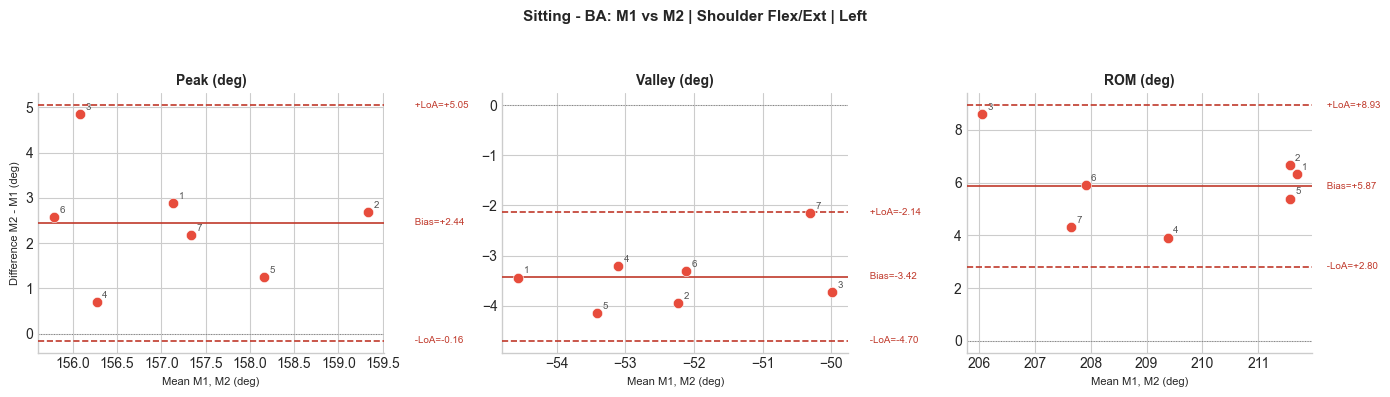

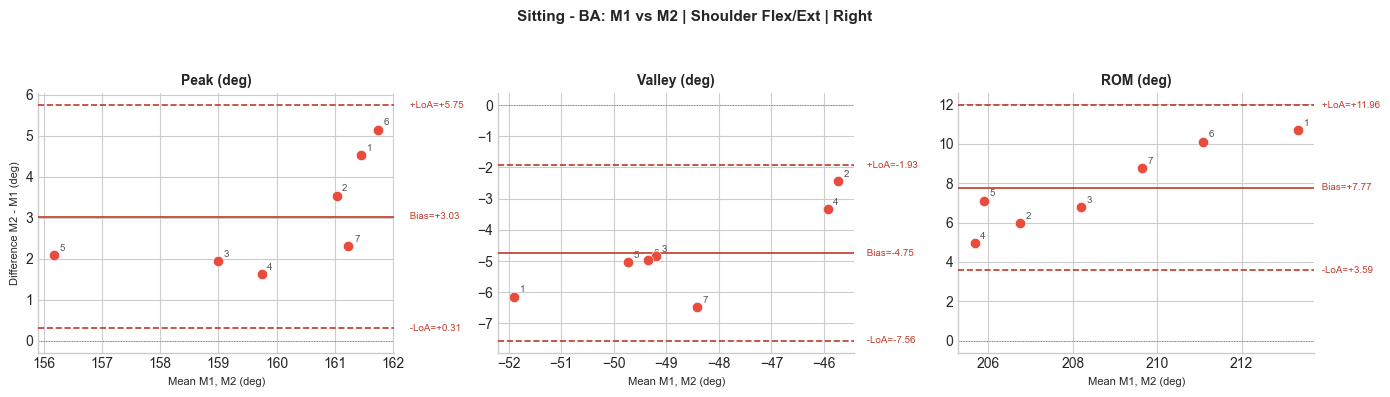

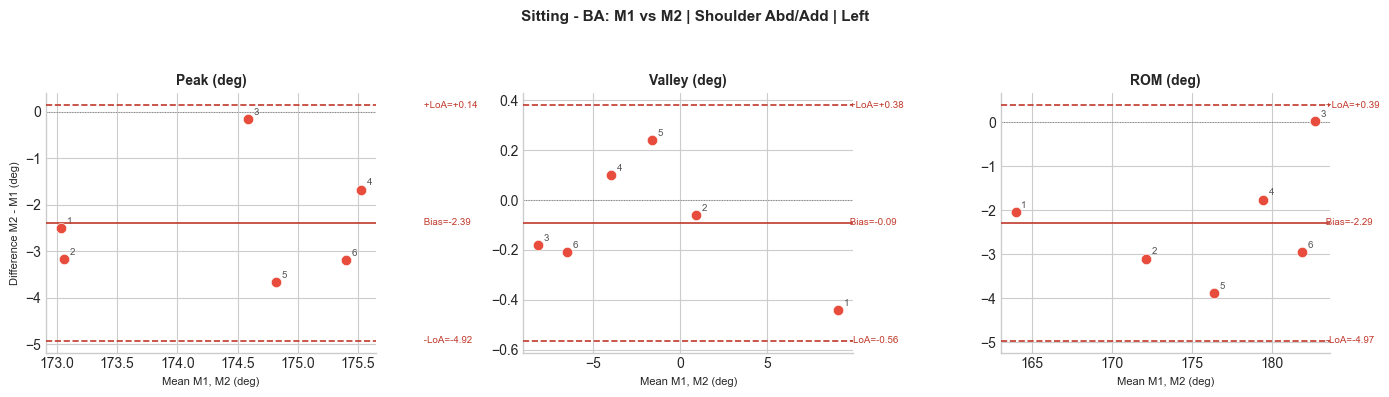

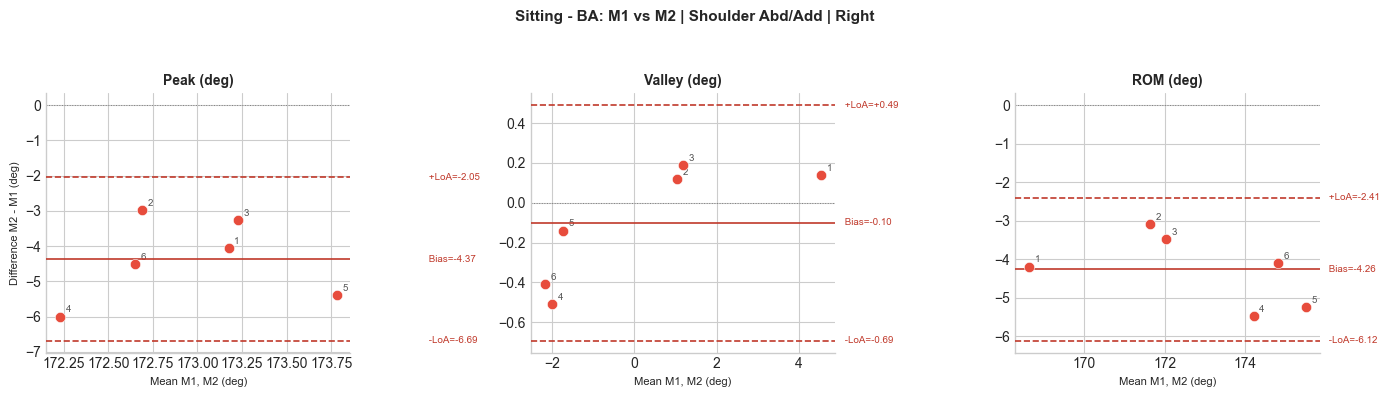

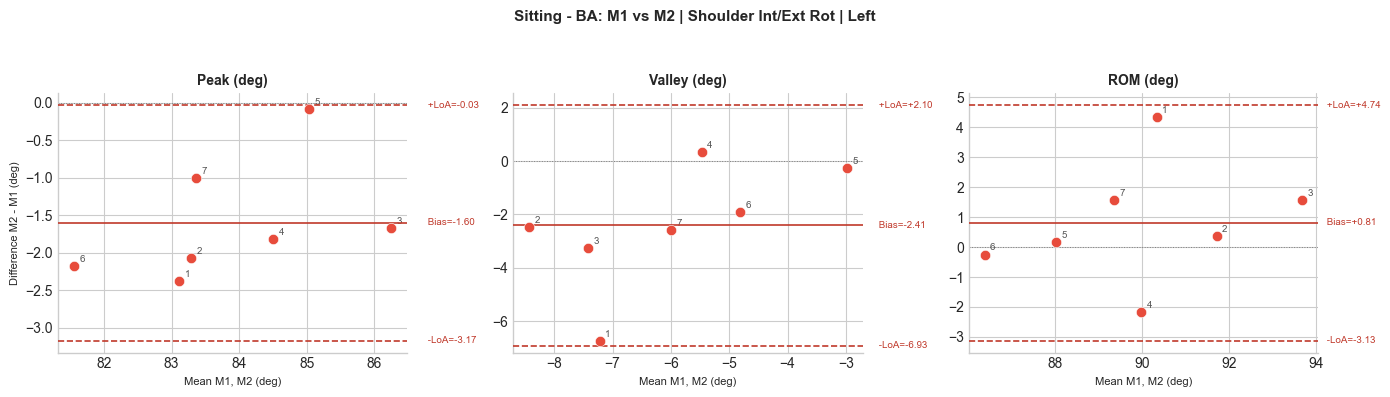

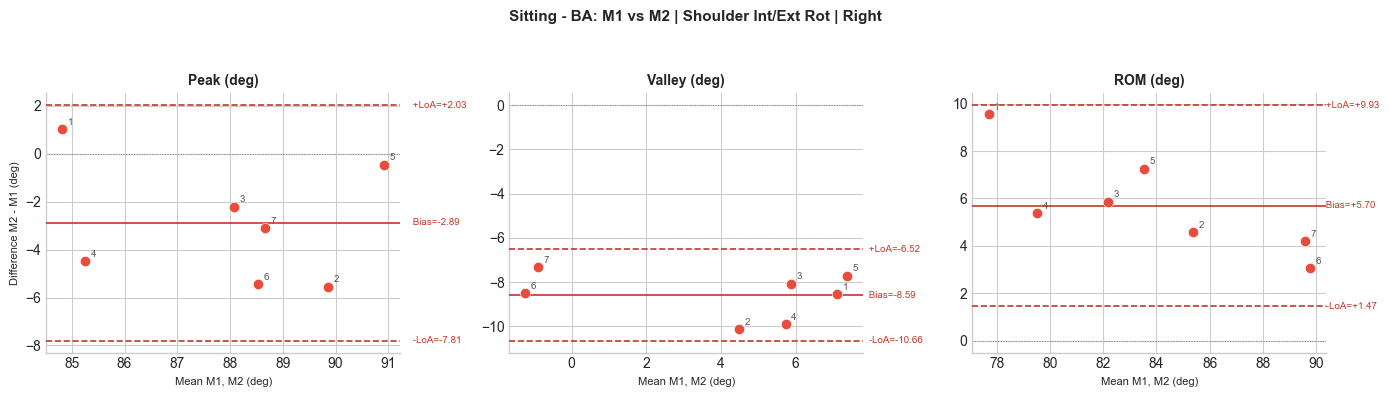

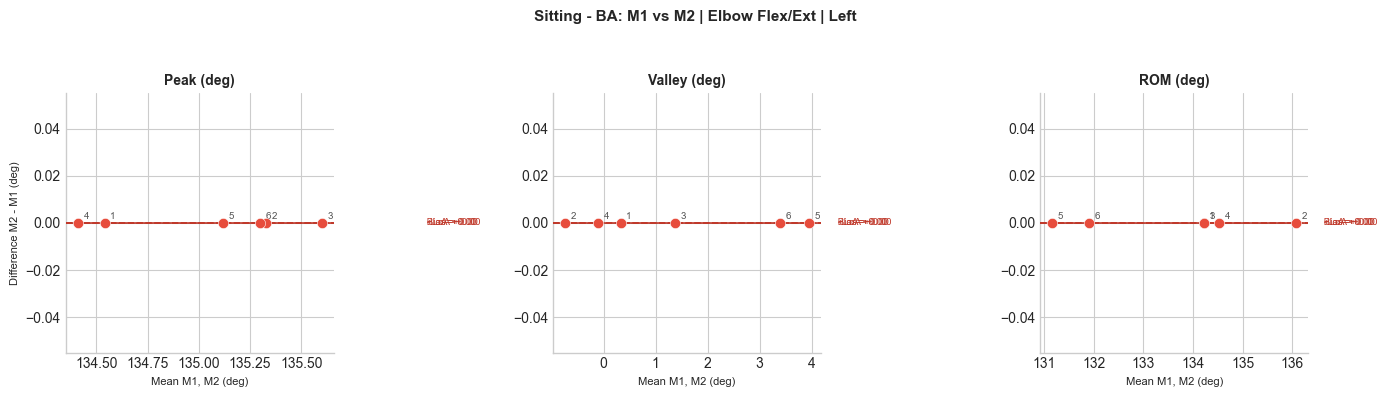

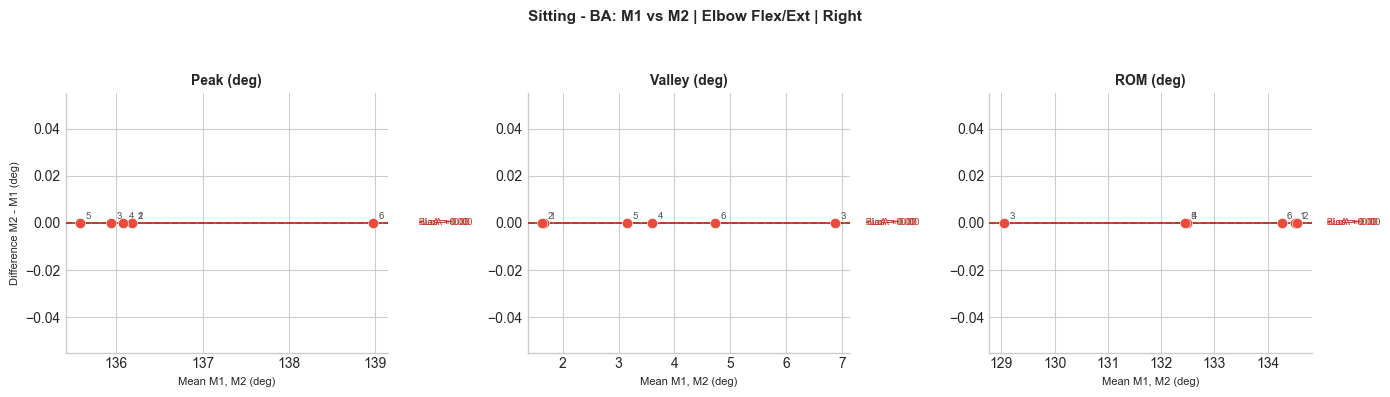

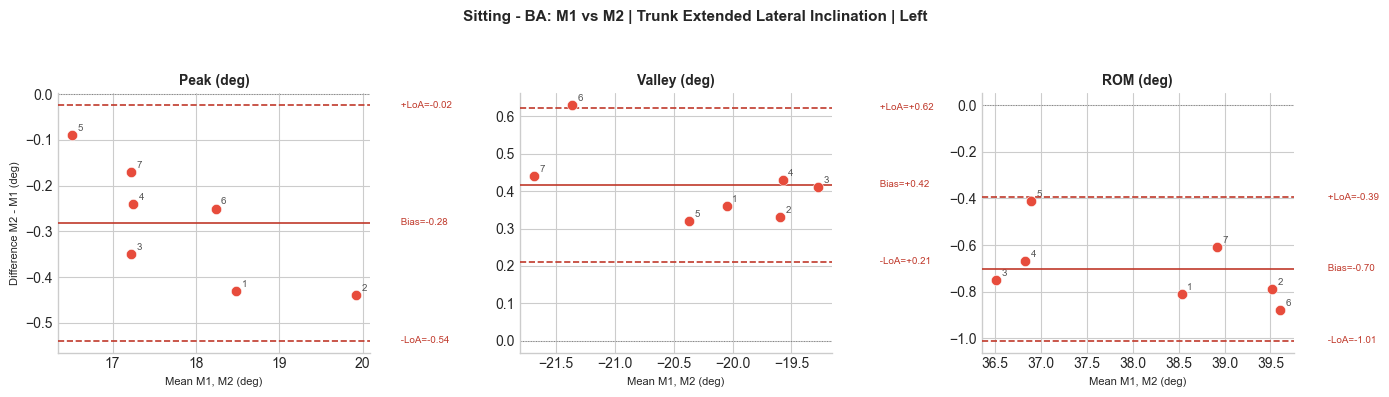

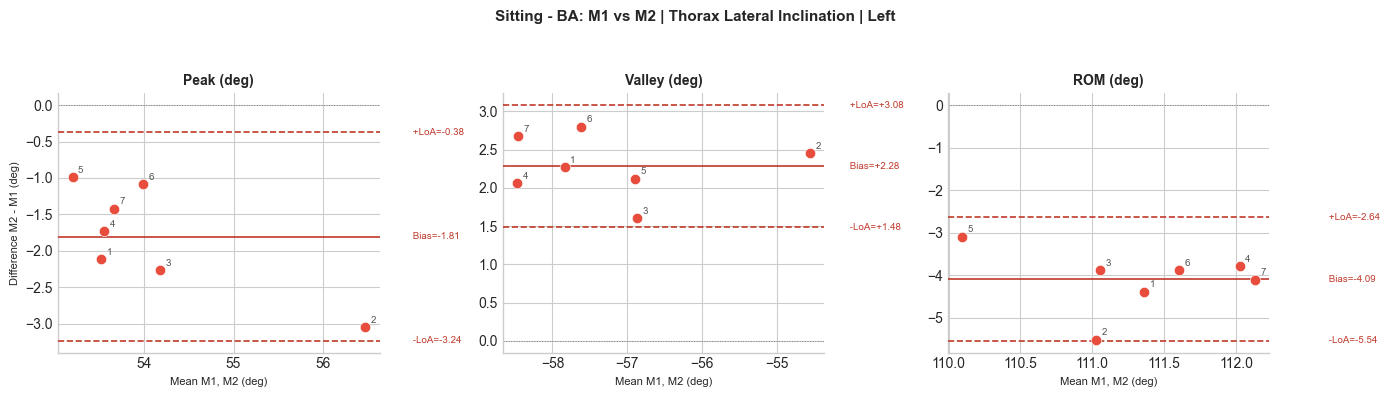

In [9]:
# Bland-Altman: one row per (movement, side), 3 cols = Peak / Valley / ROM
for movement in MOVEMENT_LIST:
    for side in get_sides(movement):
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        fig.suptitle(
            f'Sitting - BA: M1 vs M2 | {movement} | {side}',
            fontsize=11, fontweight='bold',
        )
        for ax, var in zip(axes, ANGLE_VARS):
            y_m1 = get_array(df, movement, 'M1', side, var)
            y_m2 = get_array(df, movement, 'M2', side, var)
            n    = min(len(y_m1), len(y_m2))
            means = (y_m1[:n] + y_m2[:n]) / 2
            diffs = y_m2[:n] - y_m1[:n]
            bias_v = float(np.mean(diffs))
            sd_v   = float(np.std(diffs, ddof=1))
            loa_up = bias_v + 1.96 * sd_v
            loa_lo = bias_v - 1.96 * sd_v

            ax.scatter(means, diffs, color=MODEL_COLORS['M2'],
                       s=55, zorder=4, edgecolors='white', linewidths=0.4)
            reps = df[
                (df['Movement'] == movement) & (df['Model'] == 'C7')
            ].sort_values('Rep')['Rep'].tolist()[:n]
            for mx, dy, rep in zip(means, diffs, reps):
                ax.annotate(str(rep), (mx, dy),
                            textcoords='offset points', xytext=(4, 3),
                            fontsize=7, color='#555555')
            x_right = float(means.max()) + 0.5 if len(means) else 1.0
            for val, ls, lbl in [
                (bias_v, '-',  f'Bias={bias_v:+.2f}'),
                (loa_up, '--', f'+LoA={loa_up:+.2f}'),
                (loa_lo, '--', f'-LoA={loa_lo:+.2f}'),
            ]:
                ax.axhline(val, linestyle=ls, color='#C0392B',
                           linewidth=1.2, zorder=3)
                ax.text(x_right, val, f' {lbl}', va='center', ha='left',
                        fontsize=7, color='#C0392B', clip_on=False)
            ax.axhline(0, color='gray', linewidth=0.7, linestyle=':', zorder=2)
            ax.set_title(VAR_LABELS[var], fontsize=10, fontweight='bold')
            ax.set_xlabel('Mean M1, M2 (deg)', fontsize=8)
            if ax is axes[0]:
                ax.set_ylabel('Difference M2 - M1 (deg)', fontsize=8)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        display(fig)
        plt.close(fig)


### 4.2 - ICC(C,1) Bar Chart

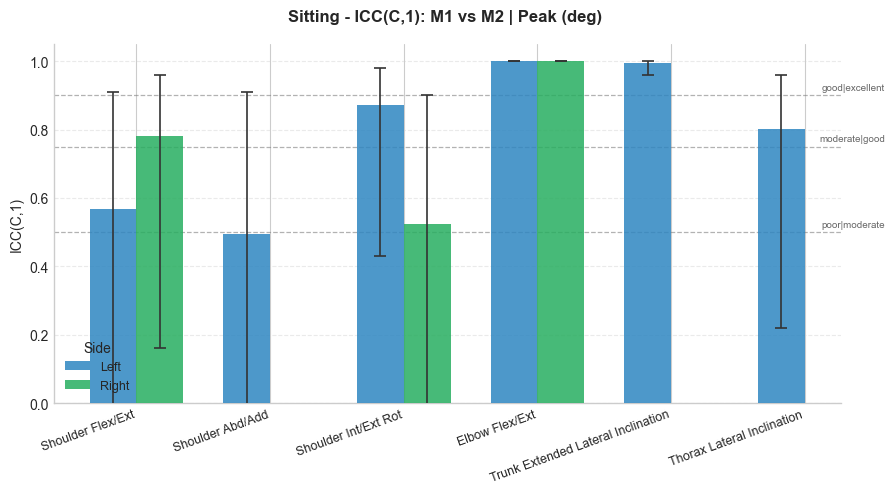

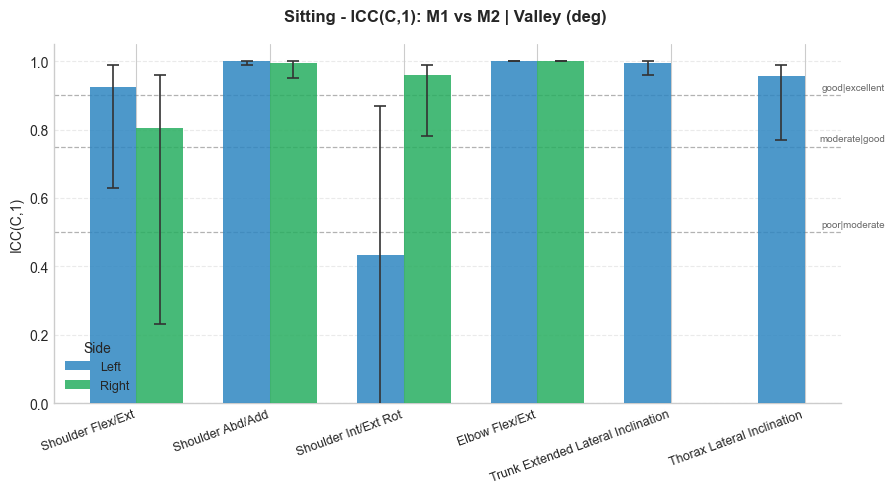

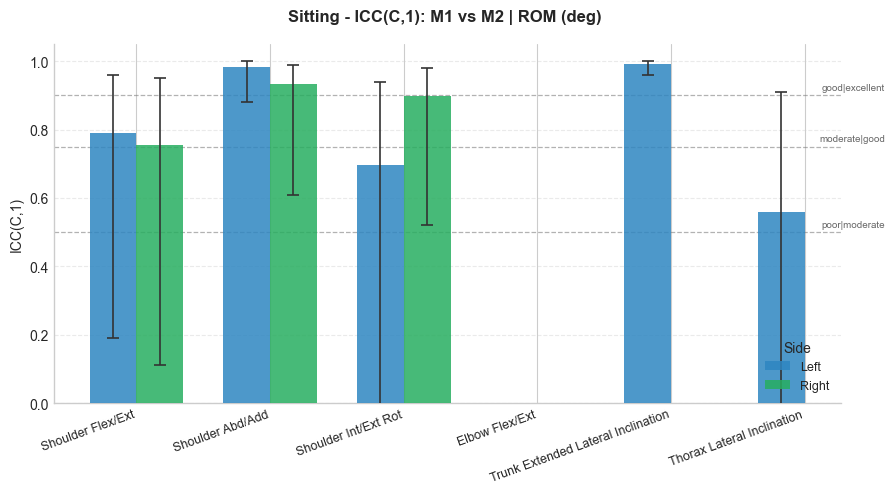

In [10]:
# ICC bar chart: one subplot per angle_var, x = movement, bar = side
for var in ANGLE_VARS:
    sub_var = df_comp[df_comp['angle_var'] == var]
    all_sides = ['Left', 'Right']
    side_colors = {'Left': '#2E86C1', 'Right': '#27AE60'}

    fig, ax = plt.subplots(figsize=(max(9, len(MOVEMENT_LIST) * 1.3), 5))
    fig.suptitle(
        f'Sitting - ICC(C,1): M1 vs M2 | {VAR_LABELS[var]}',
        fontsize=12, fontweight='bold',
    )
    x     = np.arange(len(MOVEMENT_LIST))
    width = 0.35
    for i, side in enumerate(all_sides):
        sub_side = sub_var[sub_var['side'] == side]
        icc_vals, err_lo, err_hi = [], [], []
        for mv in MOVEMENT_LIST:
            row = sub_side[sub_side['movement'] == mv]
            if mv in MOVEMENTS_BILATERAL and side == 'Right':
                icc_vals.append(np.nan)
                err_lo.append(0)
                err_hi.append(0)
            elif row.empty or np.isnan(float(row['icc'].iloc[0])):
                icc_vals.append(np.nan)
                err_lo.append(0)
                err_hi.append(0)
            else:
                v = float(row['icc'].iloc[0])
                icc_vals.append(v)
                err_lo.append(max(0.0, v - float(row['icc_ci95_lower'].iloc[0])))
                err_hi.append(max(0.0, float(row['icc_ci95_upper'].iloc[0]) - v))
        ax.bar(x + (i - 0.5) * width, icc_vals, width,
               label=side, color=side_colors[side], alpha=0.85, zorder=3)
        ax.errorbar(x + (i - 0.5) * width, icc_vals,
                    yerr=[err_lo, err_hi],
                    fmt='none', color='#333333',
                    capsize=4, capthick=1.2, elinewidth=1.2, zorder=4)
    for thresh, lbl in [
        (0.50, 'poor|moderate'),
        (0.75, 'moderate|good'),
        (0.90, 'good|excellent'),
    ]:
        ax.axhline(thresh, color='gray', linewidth=0.9, linestyle='--', alpha=0.6)
        ax.text(len(MOVEMENT_LIST) - 0.4, thresh + 0.01, lbl,
                fontsize=7, color='#666666', va='bottom', ha='right')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('ICC(C,1)', fontsize=10)
    ax.legend(title='Side', fontsize=9, framealpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(MOVEMENT_LIST, rotation=20, ha='right', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    plt.tight_layout()
    display(fig)
    plt.close(fig)


## Section 5 - Export to Excel

In [11]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

EXCEL_PATH = OUTPUT_DIR / 'validation_results_sitting.xlsx'

_HEADER_FILL  = PatternFill('solid', fgColor='C9D6E8')
_HEADER_FONT  = Font(bold=True)
_HEADER_ALIGN = Alignment(horizontal='center')
_INTERP_FILLS = {
    'poor':      PatternFill('solid', fgColor='FFCCCC'),
    'moderate':  PatternFill('solid', fgColor='FFE0B2'),
    'good':      PatternFill('solid', fgColor='FFF9C4'),
    'excellent': PatternFill('solid', fgColor='C8E6C9'),
}
_NUMERIC_COLS = {
    'n_reps', 'bias_deg', 'sd_diff_deg', 'loa_lower_deg', 'loa_upper_deg',
    'rmsd_deg', 'icc', 'icc_ci95_lower', 'icc_ci95_upper', 'shapiro_W', 'shapiro_p',
}


def _write_sheet(ws, dataframe, freeze=True):
    headers = list(dataframe.columns)
    ws.append(headers)
    for cell in ws[1]:
        cell.font      = _HEADER_FONT
        cell.fill      = _HEADER_FILL
        cell.alignment = _HEADER_ALIGN
    if freeze:
        ws.freeze_panes = 'A2'
    for row_vals in dataframe.itertuples(index=False):
        ws.append(list(row_vals))
    for ci, cn in enumerate(headers, 1):
        cl      = get_column_letter(ci)
        max_len = len(cn)
        for ri in range(2, ws.max_row + 1):
            cell = ws.cell(ri, ci)
            if cn in _NUMERIC_COLS and isinstance(cell.value, (int, float)):
                cell.number_format = '0.00'
            if cn == 'icc_interpretation' and isinstance(cell.value, str):
                cell.fill = _INTERP_FILLS.get(cell.value, PatternFill())
            max_len = max(max_len, len(str(cell.value)) if cell.value is not None else 0)
        ws.column_dimensions[cl].width = max_len + 2


wb = openpyxl.Workbook()
wb.remove(wb.active)

_write_sheet(
    wb.create_sheet('M1_vs_M2_full'),
    df_comp.drop(columns='comparison'),
)
_write_sheet(
    wb.create_sheet('Summary'),
    df_comp[['movement', 'side', 'angle_var',
             'icc', 'icc_ci95_lower', 'icc_ci95_upper', 'icc_interpretation',
             'bias_deg', 'rmsd_deg', 'zero_variance']],
)
for var in ANGLE_VARS:
    sheet_name = 'ROM_' if var == 'ROM_deg' else ('Peak_' if var == 'Peak_deg' else 'Valley_')
    sheet_name = var.replace('_deg', '')
    sub = df_comp[df_comp['angle_var'] == var].drop(
        columns=['comparison', 'angle_var']
    ).reset_index(drop=True)
    _write_sheet(wb.create_sheet(sheet_name), sub)

wb.save(EXCEL_PATH)
print(f'Excel saved: {EXCEL_PATH.name}')
print('Sheets:', [ws.title for ws in wb.worksheets])


Excel saved: validation_results_sitting.xlsx
Sheets: ['M1_vs_M2_full', 'Summary', 'Peak', 'Valley', 'ROM']
